#**An Object Identifier** : This is a project on working on a classification model that may differenciate/identify objects in an image

I will be using huggingface(hf) throughout this project , it focuses more on finetuning a model rather than traing a model from absolute scratch due to hardware and time limitation



##importing necessary libraries

In [2]:
from datasets import load_dataset
from transformers import AutoImageProcessor
import torch, torch.nn as nn
from torchvision.transforms import (
    Compose,
    RandomResizedCrop,
    RandomHorizontalFlip,
    Resize,
    CenterCrop,
    ToTensor,
    Normalize
    )
from torch.utils.data import Dataset
from PIL import Image
import matplotlib.pyplot as plt
from huggingface_hub import login, whoami

#login() into hf

In [ ]:
login()

In [ ]:
whoami()

In [6]:
import torch
device= torch.device('cuda' if torch.cuda.is_available else 'cpu')
print(device)

cuda


##loading data

**Dataset** : [ethz/food101 dataset](https://huggingface.co/datasets/ethz/food101), it consists of 75.8k train rows and 25.3k test rows

Food-101 was constructed to create a challenging fine-grained image classification benchmark for computer vision research. The 101 categories were chosen to represent dishes commonly photographed and shared on the social platform Foodspotting.com, with an intentional emphasis on visually distinct dishes to make category discrimination non-trivial.

In [7]:
df=load_dataset('ethz/food101',split='train[:50]') # split='train[:50]' only downloads the first 50 images
# initially we may only download few images to test it, the larger dataset is saved for later

README.md:   0%|          | 0.00/16.4k [00:00<?, ?B/s]

data/train-00000-of-00008.parquet: reconstructing file:   0%|          |  0.00B /  490MB            

data/train-00000-of-00008.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00008.parquet: reconstructing file:   0%|          |  0.00B /  464MB            

data/train-00001-of-00008.parquet: downloading bytes:           |  0.00B            

...

data/validation-00001-of-00003.parquet: downloading bytes:           |  0.00B            

data/validation-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  426MB            

data/validation-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

In [8]:
df

Dataset({
    features: ['image', 'label'],
    num_rows: 50
})

##visualizing an image using PIL & matplotlib

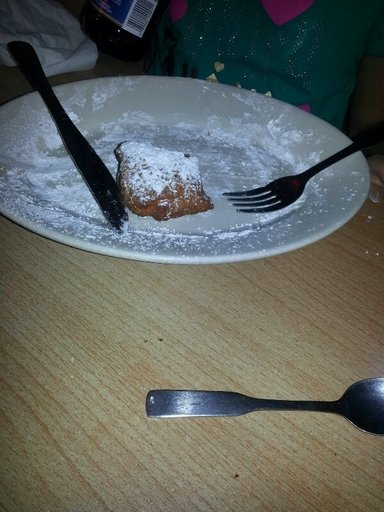

In [9]:
df['image'][0]

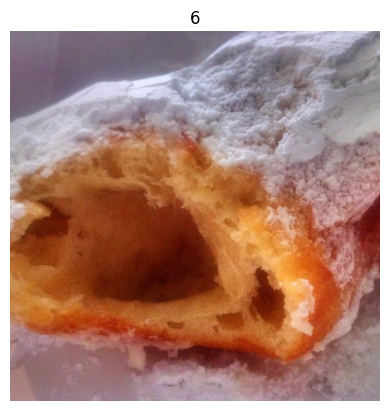

In [12]:
sample=df[20]
plt.imshow(sample['image'])
plt.axis('off')
plt.title(sample['label'])
plt.show()

##train_test_split : 70% train and 30% test data


In [17]:
x=df.train_test_split(test_size=.3,seed=42)

In [18]:
df

Dataset({
    features: ['image', 'label'],
    num_rows: 50
})

##Preprocessing & Augmentation

Image preprocessor : [google/vit-base-patch16-224-in21k](https://huggingface.co/google/vit-base-patch16-224-in21k)

The Vision Transformer (ViT) is a transformer encoder model (BERT-like) pretrained on a large collection of images in a supervised fashion, namely ImageNet-21k, at a resolution of 224x224 pixels.

In [19]:
processor=AutoImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

In [20]:
print(processor)

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

